In [16]:
from sklearn.svm import LinearSVC, SVC
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [17]:
df = pd.read_csv("../data/train_clear.csv")

In [18]:
# Использованы признаки, вошедшие в топ 10 по важности у XGBoost

important_features = [
    "Sym_Ascites",
    "Sym_Fatigue",
    "Sym_Dark_Urine",
    "Sym_Jaundice",
    "ALT",
    "AST",
    "Bilirubin",
    "Comorb_Diabetes",
    "Sym_Abdominal_Pain",
    "Sym_Itching",
]

In [19]:
target = "Liver_Disease_Type"
X = df[important_features]
y = df[target]

In [20]:
X_encoded = X.copy()

In [21]:
X_scaled = StandardScaler().fit_transform(X_encoded)

In [22]:
le = LabelEncoder()
y_encoded = np.array(le.fit_transform(y))

In [23]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

In [24]:
def train_model(model, X, y):
    all_y_true = []
    all_y_pred = []
    for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train.to_numpy(), y_train)
        print(f"{fold} фолд обучен")

        y_pred = model.predict(X_val.to_numpy())
        
        score = model.score(X_val.to_numpy(), y_val)
        cv_scores.append(score)

        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)

    scores = np.array(cv_scores)
    print(f"Точность {model.__class__.__name__}: {scores.mean():0.3f} ± {scores.std():0.3f}")

    fig, ax = plt.subplots(figsize=(8, 6))
    disp_raw = ConfusionMatrixDisplay.from_predictions(
        all_y_true, 
        all_y_pred, 
        display_labels=le.classes_,
        ax=ax,
        normalize="true"
    )
    plt.xticks(rotation=45, ha='right')

0 фолд обучен
1 фолд обучен
2 фолд обучен
3 фолд обучен
4 фолд обучен
Точность LinearSVC: 0.755 ± 0.003


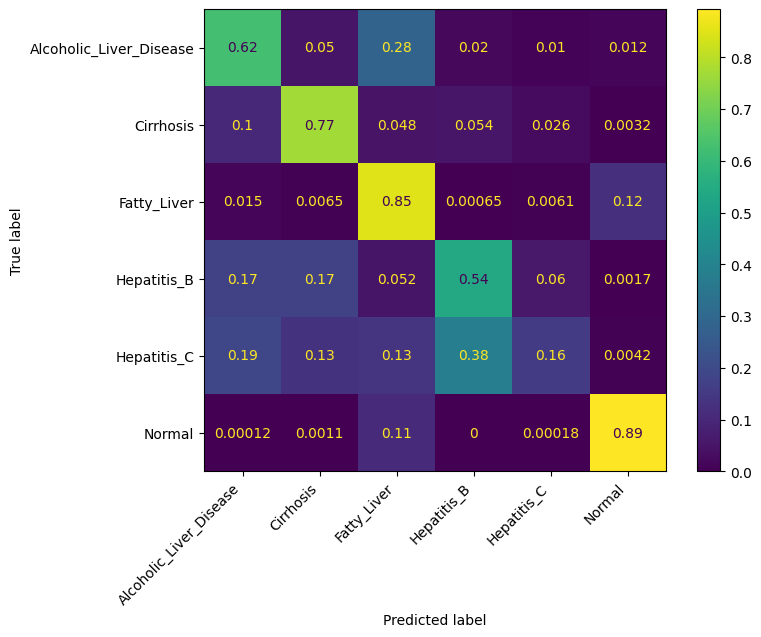

In [25]:
linear_svc = LinearSVC()
train_model(linear_svc, X_encoded, y_encoded)

0 фолд обучен
1 фолд обучен
2 фолд обучен
3 фолд обучен
4 фолд обучен
Точность SVC: 0.756 ± 0.003


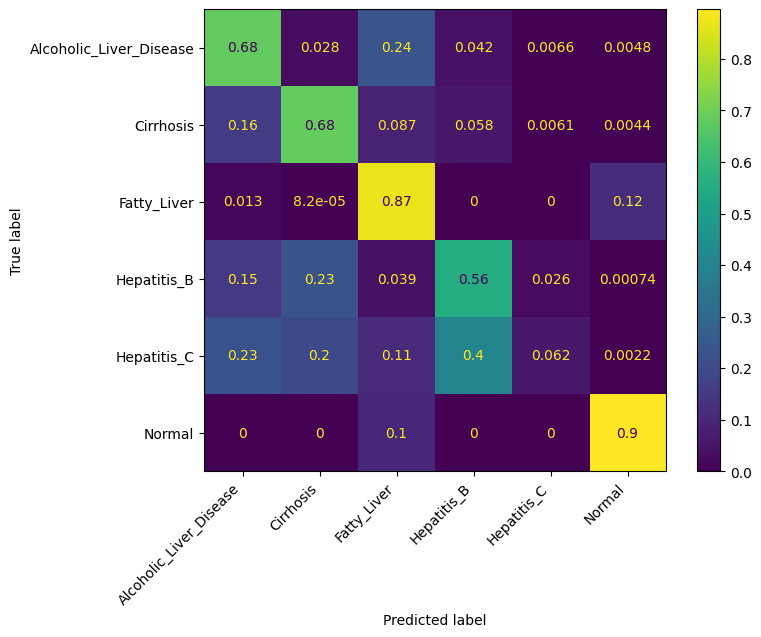

In [26]:
svc = SVC()
train_model(svc, X_encoded, y_encoded)